# Step 1: Gathering Data
1. Select a portfolio with a minimum of 5 securities. (Note that you should choose stocks for which you can find recent news, headlines, analyst reports, etc.)
2. Download daily or weekly returns for a period that allows you to have at least 100 data points (about 6 months daily returns, or 2 years of weekly returns). Assume you cannot short any securities.
3. Compute the covariance matrix from the observations.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import minimize
import cvxpy as cp

In [2]:
"""
SPY – US Large Cap
EFA – International Developed
EEM – Emerging Markets
AGG – US Bonds
HYG – High Yield Bonds
"""

'\nSPY – US Large Cap\nEFA – International Developed\nEEM – Emerging Markets\nAGG – US Bonds\nHYG – High Yield Bonds\n'

In [3]:
# clean and prepar data

tickers =['AAPL','MSFT','GOOG','AMZN','NVDA']

start_date = "2023-01-01"
end_date = "2023-06-30"

portfolio_raw = yf.download(tickers, start=start_date, end=end_date)

/tmp/ipython-input-1869899306.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_raw = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
portfolio_data = portfolio_raw.copy()
portfolio_data = portfolio_data['Close']

In [5]:
portfolio_data.columns = tickers
portfolio_data = portfolio_data.apply(pd.to_numeric, errors='coerce')

In [6]:
portfolio_daily_returns = portfolio_data.pct_change()
portfolio_daily_returns= portfolio_daily_returns.dropna()

In [7]:
portfolio_daily_returns.head()

,AAPL,MSFT,GOOG,AMZN,NVDA
Date,,,,,
2023-01-04,0.010314,-0.007924,-0.011037,-0.043743,0.030318
2023-01-05,-0.010605,-0.023726,-0.021869,-0.029638,-0.032816
2023-01-06,0.036794,0.035611,0.016019,0.011785,0.041641
2023-01-09,0.004089,0.014870,0.007259,0.009736,0.051753
2023-01-10,0.004457,0.028732,0.004955,0.007617,0.017981


In [8]:
portfolio_daily_returns.describe()

,AAPL,MSFT,GOOG,AMZN,NVDA
count,122.000000,122.000000,122.000000,122.000000,122.000000
mean,0.003523,0.003524,0.002612,0.002951,0.009251
std,0.012998,0.022400,0.021243,0.018027,0.036537
min,-0.026680,-0.084315,-0.074417,-0.043743,-0.059072
25%,-0.005627,-0.010838,-0.009851,-0.007889,-0.013848
50%,0.002308,0.001608,0.000982,0.001115,0.006348
75%,0.011064,0.018137,0.015922,0.012911,0.025964
max,0.046927,0.073799,0.072661,0.072435,0.243696



1.3. Covariance Matrix of Fama-French (5) Factors:
            AAPL        MSFT        GOOG         AMZN        NVDA
AAPL  254.488671  169.003406  170.867356   528.657442  115.863268
MSFT  169.003406  139.613901  132.240469   368.832605   83.663344
GOOG  170.867356  132.240469  141.175953   379.158052   81.461229
AMZN  528.657442  368.832605  379.158052  1154.044962  247.776367
NVDA  115.863268   83.663344   81.461229   247.776367   58.732353


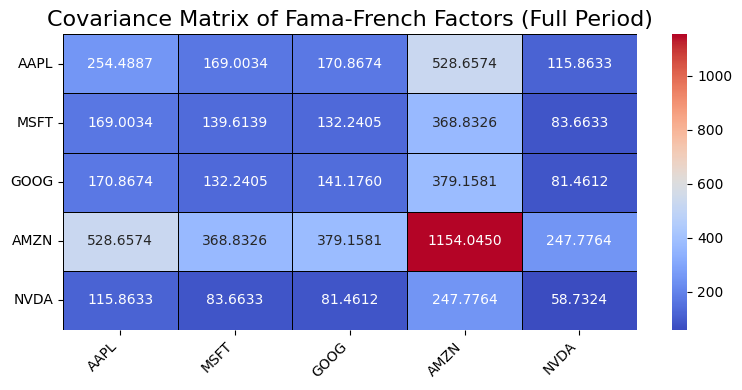

In [9]:
# Covariance Matrix
print("\n1.3. Covariance Matrix of Fama-French (5) Factors:")
covariance_matrix_full = portfolio_data.cov()
print(covariance_matrix_full.round(8)) # Show more decimals as values can be very small

plt.figure(figsize=(8,4 ))
sns.heatmap(covariance_matrix_full, annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5, linecolor='black')
plt.title('Covariance Matrix of Fama-French Factors (Full Period)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
print("Selected tickers:", portfolio_daily_returns.columns.tolist())
print("Selected tickers:", portfolio_daily_returns.columns.tolist())
print("Shape of return data:", portfolio_daily_returns.shape)
print("Missing values per column:\n", portfolio_daily_returns.isnull().sum())
portfolio_daily_returns.cov()

Selected tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Selected tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Shape of return data: (122, 5)
Missing values per column:
 AAPL    0
MSFT    0
GOOG    0
AMZN    0
NVDA    0
dtype: int64


,AAPL,MSFT,GOOG,AMZN,NVDA
AAPL,0.000169,0.000161,0.000168,0.000136,0.000197
MSFT,0.000161,0.000502,0.000304,0.000260,0.000243
GOOG,0.000168,0.000304,0.000451,0.000244,0.000274
AMZN,0.000136,0.000260,0.000244,0.000325,0.000352
NVDA,0.000197,0.000243,0.000274,0.000352,0.001335


In [11]:
# Calculate risk-free rate during the period
rf = yf.download('^TNX', start=start_date, end=end_date)
rf_rate = rf['Close'].mean().item()

/tmp/ipython-input-2622429574.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rf = yf.download('^TNX', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [12]:
rf_rate

3.6225365875213127

In [13]:
rf_annual = rf_rate/100  # Convert from percent to decimal
rf_daily = rf_annual / 252
print(f"Risk-free rate (annual): {rf_annual:.2%}")
print(f"Risk-free rate (daily): {rf_daily:.2%}")

Risk-free rate (annual): 3.62%
Risk-free rate (daily): 0.01%


# Step 2: Markowitz Optimization
1. Run a classical Markowitz portfolio optimization.
2. Be sure to print / display / graph the weights of each security in the portfolio
optimization results.

In [14]:
# Step 1: Calculate expected returns and covariance matrix
mean_returns = portfolio_daily_returns.mean()
cov_matrix = portfolio_daily_returns.cov()

# Step 2: Set constraints and bounds
num_assets = len(mean_returns)
bounds = tuple((0, 1) for _ in range(num_assets))  # No shorting
#min_weight = 0.05 # minimum weight 5%
constraints = [{'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}]  # Weights sum to 1

In [15]:
for i in range(num_assets):
    #constraints.append({'type': 'ineq', 'fun': lambda weights, i=i: weights[i] - min_weight})
    constraints.append({'type': 'ineq', 'fun': lambda weights, i=i: weights[i]})


# Convert the list to a tuple for the optimizer
constraints = tuple(constraints)

In [16]:
# Step 3: Define functions for portfolio metrics
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def negative_return(weights):
    return -portfolio_performance(weights, mean_returns, cov_matrix)[0]

def negative_sharpe(weights):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = (ret - rf_daily) / vol
    return -sharpe

def minimize_volatility(weights):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]


In [17]:
# Step 4: Initial guess (equal weights)
init_guess = num_assets * [1/num_assets]

# Step 5: Run optimization
objective = 'sharpe'

if objective == 'volatility':
    target_fn = minimize_volatility
elif objective == 'return':
    target_fn = negative_return
elif objective == 'sharpe':
    target_fn = negative_sharpe
else:
    raise ValueError("Invalid objective selected.")

optimized = minimize(target_fn, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

In [18]:
# Step 6: Extract results
opt_weights = optimized.x
expected_return, expected_volatility = portfolio_performance(opt_weights, mean_returns, cov_matrix)

markowitz_ret = expected_return * 252
markowitz_vol = expected_volatility * np.sqrt(252)
markowitz_sharpe = (markowitz_ret - rf_annual) / markowitz_vol

# Print results
print("Markowitz Optimal Portfolio:")
for ticker, weight in zip(portfolio_daily_returns.columns, opt_weights):
    print(f"{ticker}: {weight:.4f}")
print(f"\nExpected Annualized Return: {expected_return * 252:.2%}")
print(f"Expected Annualized Volatility: {expected_volatility * np.sqrt(252):.2%}")
print(f"Markowitz Sharpe Ratio: {markowitz_sharpe:.2f}")

Markowitz Optimal Portfolio:
AAPL: 0.7573
MSFT: 0.0000
GOOG: 0.0000
AMZN: 0.0000
NVDA: 0.2427

Expected Annualized Return: 123.81%
Expected Annualized Volatility: 24.99%
Markowitz Sharpe Ratio: 4.81


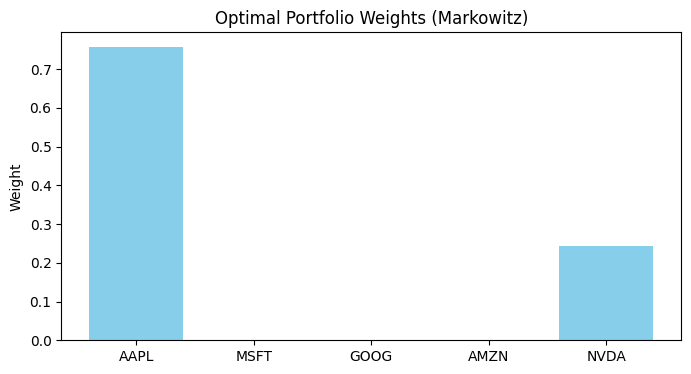

In [19]:
# Chart of weights
plt.figure(figsize=(8, 4))
plt.bar(portfolio_daily_returns.columns, opt_weights, color='skyblue')
plt.title('Optimal Portfolio Weights (Markowitz)')
plt.ylabel('Weight')
plt.show()

# Step 3: Random Strategy Optimization
1. Individually, each student addresses 1/N portfolio strategy

  a. Use Monte Carlo simulation to allocate equally across randomly selected portfolios. Note: the data will be actual historical data, but the weights are randomly selected.

  b. Perform a series of historical back-tests to see how the combined portfolio performs. The students will compare their results with each other; Please include all 3 sets of code in the final submission, as each student should code their own version of this step.

2. Collectively, the students summarize the findings by comparing to 1/N strategy with the Markowitz strategy. For example, how did the allocations hold for the following 3-month period?

In [20]:
# download 3-Month Forward Price Data for back test
backtest_prices = yf.download(tickers, start="2023-08-01", end="2024-10-30")['Close']
backtest_returns = backtest_prices.pct_change().dropna()

/tmp/ipython-input-2874523313.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  backtest_prices = yf.download(tickers, start="2023-08-01", end="2024-10-30")['Close']
[*********************100%***********************]  5 of 5 completed


In [21]:
backtest_returns.head()

Ticker,AAPL,AMZN,GOOG,MSFT,NVDA
Date,,,,,
2023-08-02,-0.015490,-0.026426,-0.024642,-0.026283,-0.048122
2023-08-03,-0.007322,0.005460,0.001011,-0.002565,0.005557
2023-08-04,-0.048020,0.082693,-0.001786,0.003429,0.003707
2023-08-07,-0.017254,0.018987,0.026451,0.007108,0.016495
2023-08-08,0.005312,-0.016031,-0.000758,-0.012299,-0.016580


## Member 1

In [22]:
# Member 1
np.random.seed(123)
# 2.1 Monte Carlo simulation for equally weighted portfolio (1/N)
equal_weights = np.array([1/num_assets] * num_assets)
eq_return = np.dot(equal_weights, mean_returns) * 252
eq_vol = np.sqrt(np.dot(equal_weights.T, np.dot(cov_matrix, equal_weights))) * np.sqrt(252)
eq_sharpe = (eq_return - rf_annual) / eq_vol


print("Equal-Weight Portfolio:")
for ticker, weight in zip(portfolio_daily_returns.columns, equal_weights):
    print(f"{ticker}: {weight:.2f}")
print(f"\nAnnualized Return: {eq_return:.2%}")
print(f"Annualized Volatility: {eq_vol:.2%}")
print(f"Equal-Weight Sharpe Ratio: {eq_sharpe:.2f}")

# === 2. Monte Carlo Simulation
num_portfolios = 10000
results_1 = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    ret = np.dot(weights, mean_returns) * 252
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Use the risk-free rate
    sharpe = (ret - rf_annual) / vol

    results_1[0, i] = ret
    results_1[1, i] = vol
    results_1[2, i] = sharpe

Equal-Weight Portfolio:
AAPL: 0.20
MSFT: 0.20
GOOG: 0.20
AMZN: 0.20
NVDA: 0.20

Annualized Return: 110.18%
Annualized Volatility: 27.42%
Equal-Weight Sharpe Ratio: 3.89


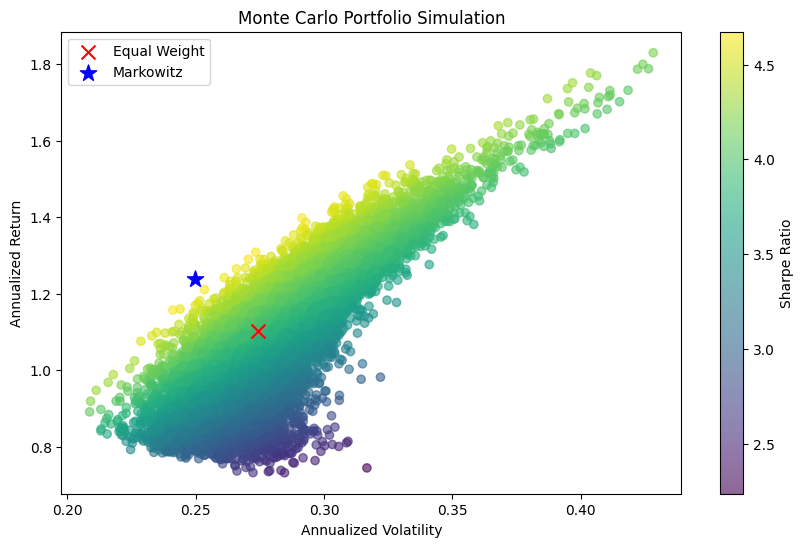

In [23]:
# Convert results to DataFrame
results_df_1 = pd.DataFrame(results_1.T, columns=['Return', 'Volatility', 'Sharpe'])
weights_df_1 = pd.DataFrame(weights_record, columns=portfolio_daily_returns.columns)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(results_df_1['Volatility'], results_df_1['Return'], c=results_df_1['Sharpe'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.title('Monte Carlo Portfolio Simulation')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')

# Highlight equal-weight and Markowitz portfolios
plt.scatter(eq_vol, eq_return, color='red', marker='x', s=100, label='Equal Weight')
plt.scatter(expected_volatility * np.sqrt(252), expected_return * 252, color='blue', marker='*', s=150, label='Markowitz')
plt.legend()
plt.show()

In [24]:
# Combine weights and simulation results
combined_df = pd.concat([results_df_1, weights_df_1], axis=1)

# Sort portfolios by Sharpe ratio
top_portfolios = combined_df.sort_values(by='Sharpe', ascending=False).head()

# Display top 5 random portfolios
print("Top 5 Portfolios by Sharpe Ratio:")
print(top_portfolios)

# Display best random portfolio
print("\nBest Random Portfolio Weights:")
best_portfolio = top_portfolios.iloc[0]
best_portfolio_weight = best_portfolio.tail(5).values

for ticker in portfolio_daily_returns.columns:
    print(f"{ticker}: {best_portfolio[ticker]:.4f}")


# Print performance metrics
print(f"\nSharpe Ratio: {best_portfolio['Sharpe']:.4f}")
print(f"Annual Return: {best_portfolio['Return']:.4%}")
print(f"Annual Volatility: {best_portfolio['Volatility']:.4%}")


Top 5 Portfolios by Sharpe Ratio:
        Return  Volatility    Sharpe      AAPL      MSFT      GOOG      AMZN  \
5324  1.398163    0.291447  4.673013  0.540941  0.066603  0.013338  0.021272   
2973  1.308432    0.273404  4.653206  0.548970  0.050001  0.009056  0.090097   
895   1.157331    0.241125  4.649477  0.655781  0.022825  0.041742  0.078412   
2588  1.210888    0.253423  4.635196  0.565520  0.107783  0.028868  0.063088   
4662  1.289904    0.270575  4.633387  0.541202  0.053829  0.033912  0.079158   

          NVDA  
5324  0.357846  
2973  0.301876  
895   0.201240  
2588  0.234741  
4662  0.291899  

Best Random Portfolio Weights:
AAPL: 0.5409
MSFT: 0.0666
GOOG: 0.0133
AMZN: 0.0213
NVDA: 0.3578

Sharpe Ratio: 4.6730
Annual Return: 139.8163%
Annual Volatility: 29.1447%


In [25]:
# Create summary DataFrame
train_summary = pd.DataFrame({
    'Return (3M)': [eq_return, markowitz_ret, best_portfolio['Return']],
    'Volatility (Annualized)': [eq_vol, markowitz_vol , best_portfolio['Volatility']],
    'Sharpe Ratio': [eq_sharpe, markowitz_sharpe, best_portfolio['Sharpe']]
}, index=['Equal-Weight', 'Markowitz', 'Monte Carlo(1) - Max Sharpe Ratio'])


# Display the formatted summary
print("Train Summary:")
display(train_summary.style.format({
    'Return (3M)': '{:.2%}',
    'Volatility (Annualized)': '{:.2%}',
    'Sharpe Ratio': '{:.4f}'
}))

Train Summary:


,Return (3M),Volatility (Annualized),Sharpe Ratio
Equal-Weight,110.18%,27.42%,3.8863
Markowitz,123.81%,24.99%,4.8094
Monte Carlo(1) - Max Sharpe Ratio,139.82%,29.14%,4.6730


In [26]:
## back testing
# Define portfolio weights
equal_weights_1 = np.array(equal_weights)
markowitz_weights_1 = np.array(opt_weights)
best_random_weights_1 = best_portfolio_weight

# Calculate daily portfolio returns
def get_portfolio_returns(returns, weights):
    return returns.dot(weights)

eq_portfolio_ret_1 = get_portfolio_returns(backtest_returns, equal_weights_1)
mw_portfolio_ret_1 = get_portfolio_returns(backtest_returns, markowitz_weights_1)
rnd_portfolio_ret_1 = get_portfolio_returns(backtest_returns, best_random_weights_1)

# Calculate cumulative return over 3 months
eq_cum_return_1 = (1 + eq_portfolio_ret_1).prod() - 1
mw_cum_return_1 = (1 + mw_portfolio_ret_1).prod() - 1
rnd_cum_return_1 = (1 + rnd_portfolio_ret_1).prod() - 1

# Annualised volatility
eq_portfolio_vol_1 = np.std(eq_portfolio_ret_1) * np.sqrt(252)
mw_portfolio_vol_1 = np.std(mw_portfolio_ret_1) * np.sqrt(252)
rnd_portfolio_vol_1 = np.std(rnd_portfolio_ret_1) * np.sqrt(252)

# Sharpe ratio
eq_portfolio_sharpe_1 = (np.mean(eq_portfolio_ret_1) * 252 - rf_annual) / eq_portfolio_vol_1
mw_portfolio_sharpe_1 = (np.mean(mw_portfolio_ret_1) * 252 - rf_annual) / mw_portfolio_vol_1
rnd_portfolio_sharpe_1 = (np.mean(rnd_portfolio_ret_1) * 252 - rf_annual) / rnd_portfolio_vol_1

In [27]:
# Create summary DataFrame
backtest_summary_1 = pd.DataFrame({
    'Cumulative Return (3M)': [eq_cum_return_1, mw_cum_return_1, rnd_cum_return_1],
    'Volatility (Annualized)': [eq_portfolio_vol_1, mw_portfolio_vol_1, rnd_portfolio_vol_1],
    'Sharpe Ratio': [eq_portfolio_sharpe_1, mw_portfolio_sharpe_1, rnd_portfolio_sharpe_1]
}, index=['Equal-Weight', 'Markowitz', 'Monte Carlo(1) - Max Sharpe Ratio'])


# Display the formatted summary
print("3-Month Backtest Results(Member 1):")
display(backtest_summary_1.style.format({
    'Cumulative Return (3M)': '{:.2%}',
    'Volatility (Annualized)': '{:.2%}',
    'Sharpe Ratio': '{:.4f}'
}))

3-Month Backtest Results(Member 1):


,Cumulative Return (3M),Volatility (Annualized),Sharpe Ratio
Equal-Weight,59.69%,22.05%,1.6509
Markowitz,54.53%,23.81%,1.4347
Monte Carlo(1) - Max Sharpe Ratio,76.05%,25.98%,1.7393


## Member 2


Starting Portfolio Optimization (Monte Carlo Simulation)...

Portfolio Optimization Complete.
Optimal Portfolio (Max Sharpe Ratio):
  Annualized Return: 130.8432%
  Annualized Volatility: 27.3404%
  Sharpe Ratio: 4.6532
  Optimal Weights:
    AAPL: 0.5490
    MSFT: 0.0500
    GOOG: 0.0091
    AMZN: 0.0901
    NVDA: 0.3019


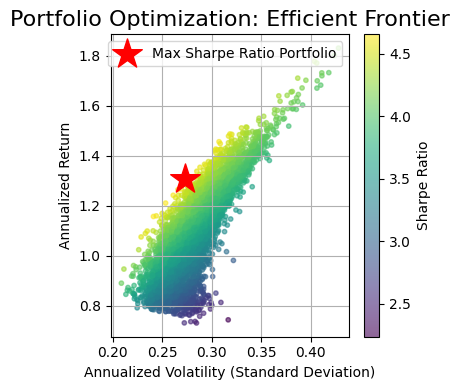


Optimized Portfolio Daily Returns Head:
Date
2023-01-04    0.010377
2023-01-05   -0.019783
2023-01-06    0.035757
2023-01-09    0.019554
2023-01-10    0.010042
dtype: float64


In [28]:
# Portfolio Optimization (Maximizing Sharpe Ratio)
np.random.seed(123)
num_portfolios = 5000 # Number of random portfolios to generate
results_2 = np.zeros((3 + len(tickers), num_portfolios)) # For returns, volatility, sharpe, and weights

mean_daily_returns = portfolio_daily_returns.mean()
cov_matrix = portfolio_daily_returns.cov()
annual_risk_free_rate = rf_annual # Annualize daily RF rate

print("\nStarting Portfolio Optimization (Monte Carlo Simulation)...")

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights) # Normalize weights to sum to 1

    portfolio_return = np.sum(mean_daily_returns * weights) * 252 # Annualized return
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252) # Annualized volatility

    sharpe_ratio = (portfolio_return - annual_risk_free_rate) / portfolio_std_dev

    results_2[0, i] = portfolio_return
    results_2[1, i] = portfolio_std_dev
    results_2[2, i] = sharpe_ratio
    for j in range(len(weights)):
        results_2[j+3, i] = weights[j]

results_df_2 = pd.DataFrame(results_2.T, columns=['Return', 'Volatility', 'Sharpe Ratio'] + [ticker + '_Weight' for ticker in tickers])

# Find the portfolio with the maximum Sharpe Ratio
max_sharpe_portfolio = results_df_2.loc[results_df_2['Sharpe Ratio'].idxmax()]

print("\nPortfolio Optimization Complete.")
print("Optimal Portfolio (Max Sharpe Ratio):")
print(f"  Annualized Return: {max_sharpe_portfolio['Return']:.4%}")
print(f"  Annualized Volatility: {max_sharpe_portfolio['Volatility']:.4%}")
print(f"  Sharpe Ratio: {max_sharpe_portfolio['Sharpe Ratio']:.4f}")
print("  Optimal Weights:")
for ticker in tickers:
    print(f"    {ticker}: {max_sharpe_portfolio[ticker + '_Weight']:.4f}")

# Plotting the efficient frontier
plt.figure(figsize=(4, 4))
plt.scatter(results_df_2['Volatility'], results_df_2['Return'], c=results_df_2['Sharpe Ratio'], cmap='viridis', marker='o', s=10, alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Return'], marker='*', color='red', s=500, label='Max Sharpe Ratio Portfolio')
plt.title('Portfolio Optimization: Efficient Frontier', fontsize=16)
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 7.c. Calculate Optimized Portfolio's Daily Returns
optimal_weights_2 = np.array([max_sharpe_portfolio[ticker + '_Weight'] for ticker in tickers])
optimized_portfolio_daily_returns = (portfolio_daily_returns * optimal_weights_2).sum(axis=1)

print("\nOptimized Portfolio Daily Returns Head:")
print(optimized_portfolio_daily_returns.head())

In [29]:
# Define portfolio weights
equal_weights_2 = np.array([0.2] * 5)
best_random_weights_2 = np.array(optimal_weights_2)

# Calculate daily portfolio returns
def get_portfolio_returns(returns, weights):
    return returns.dot(weights)

eq_portfolio_ret_2 = get_portfolio_returns(backtest_returns, equal_weights_2)
rnd_portfolio_ret_2 = get_portfolio_returns(backtest_returns, best_random_weights_2)

# Calculate cumulative return over 3 months
eq_cum_return_2 = (1 + eq_portfolio_ret_2).prod() - 1
rnd_cum_return_2 = (1 + rnd_portfolio_ret_2).prod() - 1

# Annualised volatility
eq_portfolio_vol_2 = np.std(eq_portfolio_ret_2) * np.sqrt(252)
rnd_portfolio_vol_2 = np.std(rnd_portfolio_ret_2) * np.sqrt(252)

# Sharpe ratio
eq_portfolio_sharpe_2 = (np.mean(eq_portfolio_ret_2) * 252 - rf_annual) / eq_portfolio_vol_2
rnd_portfolio_sharpe_2 = (np.mean(rnd_portfolio_ret_2) * 252 - rf_annual) / rnd_portfolio_vol_2

In [30]:
print("3-Month Backtest Results(Member 2):")
print(f"Equal-Weight:  Return = {eq_cum_return_2:.4%}, Volatility = {eq_portfolio_vol_2:.4%}, Sharpe = {eq_portfolio_sharpe_2:.4f}")
print(f"Best Random:   Return = {rnd_cum_return_2:.4%}, Volatility = {rnd_portfolio_vol_2:.4%}, Sharpe = {rnd_portfolio_sharpe_2:.4f}")

3-Month Backtest Results(Member 2):
Equal-Weight:  Return = 59.6886%, Volatility = 22.0513%, Sharpe = 1.6509
Best Random:   Return = 67.0576%, Volatility = 24.2252%, Sharpe = 1.6729


## Member 3:


Student 3: Equal Weight (1/N) Portfolio Weights:
AAPL: 0.2000
MSFT: 0.2000
GOOG: 0.2000
AMZN: 0.2000
NVDA: 0.2000

--- Optimal Portfolio: Maximum Sharpe Ratio ---
Annualized Return: 1.3982
Annualized Volatility: 0.2914
Sharpe Ratio: 4.6730

Optimal Weights:
  AAPL: 0.5409
  MSFT: 0.0666
  GOOG: 0.0133
  AMZN: 0.0213
  NVDA: 0.3578


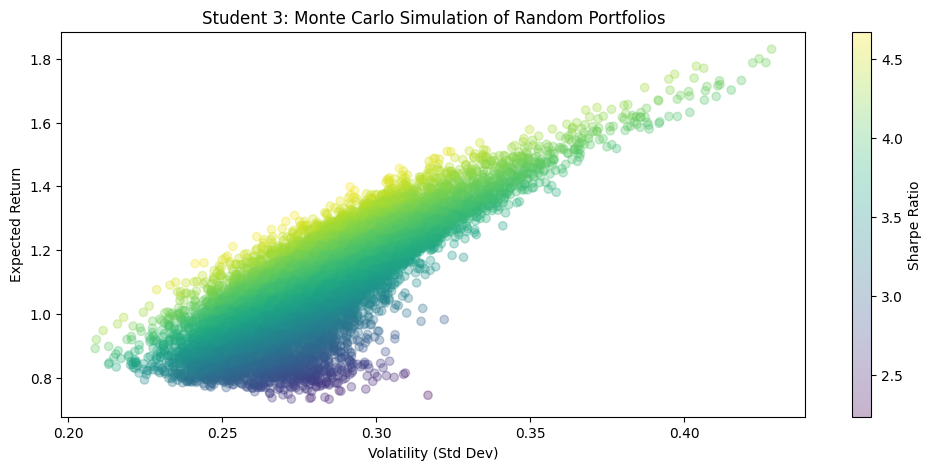

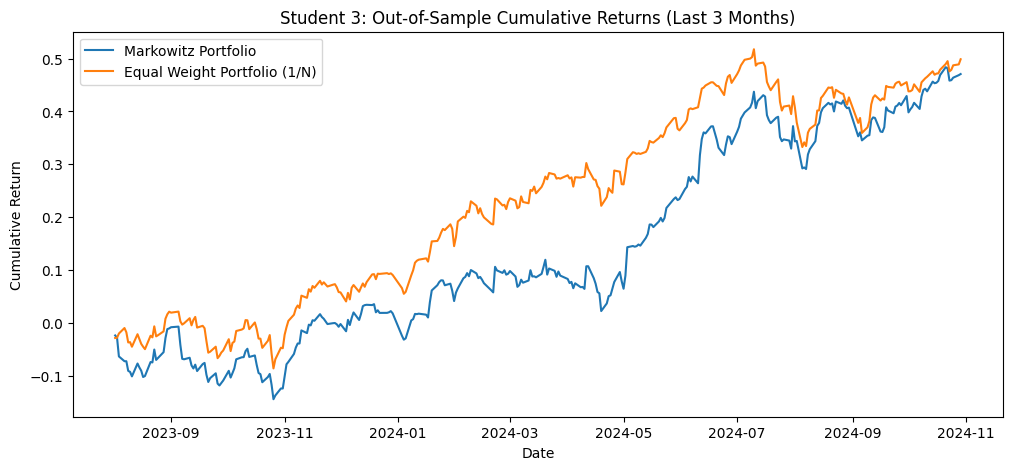

In [31]:
# Student 3: Random Strategy Optimization
np.random.seed(123)

# 3a. 1/N equal-weighted portfolio
equal_weights_s3 = np.ones(num_assets) / num_assets
print("\nStudent 3: Equal Weight (1/N) Portfolio Weights:")
for ticker, w_eq in zip(tickers, equal_weights_s3):
    print(f"{ticker}: {w_eq:.4f}")

# 3b. Monte Carlo Simulation of random portfolios
num_portfolios = 10000
results_s3 = np.zeros((num_portfolios, 3))
weights_record_s3 = []
risk_free_rate = rf_annual

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_daily_returns) * 252 # Annualized return
    port_var = np.dot(weights.T, np.dot(cov_matrix.values, weights))
    port_vol = np.sqrt(port_var) * np.sqrt(252) # Annualized volatility

    sharpe = (port_return - risk_free_rate) / port_vol

    results_s3[i] = [port_vol, port_return, sharpe]
    weights_record_s3.append(weights)

results_df_s3 = pd.DataFrame(results_s3, columns=['Volatility', 'Return', 'Sharpe'])

max_sharpe_idx_3 = results_df_s3['Sharpe'].idxmax()
max_sharpe_portfolio_3 = results_df_s3.loc[max_sharpe_idx_3]
max_sharpe_weights_3 = weights_record_s3[max_sharpe_idx_3]

print("\n--- Optimal Portfolio: Maximum Sharpe Ratio ---")
print(f"Annualized Return: {max_sharpe_portfolio_3['Return']:.4f}")
print(f"Annualized Volatility: {max_sharpe_portfolio_3['Volatility']:.4f}")
print(f"Sharpe Ratio: {max_sharpe_portfolio_3['Sharpe']:.4f}\n")

print("Optimal Weights:")
for ticker, weight in zip(tickers, max_sharpe_weights_3):
    print(f"  {ticker}: {weight:.4f}")


plt.figure(figsize=(12, 5))
plt.scatter(results_df_s3['Volatility'], results_df_s3['Return'], c=results_df_s3['Sharpe'], cmap='viridis', alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Student 3: Monte Carlo Simulation of Random Portfolios')
plt.show()

# 3c. Backtesting with last 3 months (~13 weeks)
def portfolio_cumulative_return(weights, returns_df):
    return (returns_df @ weights).cumsum()

oos_returns = backtest_returns
markowitz_returns_oos_s3 = portfolio_cumulative_return(opt_weights, oos_returns)
eq_returns_oos_s3 = portfolio_cumulative_return(equal_weights_s3, oos_returns)

plt.figure(figsize=(12, 5))
plt.plot(markowitz_returns_oos_s3, label='Markowitz Portfolio')
plt.plot(eq_returns_oos_s3, label='Equal Weight Portfolio (1/N)')
plt.title('Student 3: Out-of-Sample Cumulative Returns (Last 3 Months)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [32]:
# Define portfolio weights
equal_weights_3 = np.array([0.2] * 5)
best_random_weights_3 = np.array(max_sharpe_weights_3)

# Calculate daily portfolio returns
def get_portfolio_returns(returns, weights):
    return returns.dot(weights)

eq_portfolio_ret_3 = get_portfolio_returns(backtest_returns, equal_weights_3)
rnd_portfolio_ret_3 = get_portfolio_returns(backtest_returns, best_random_weights_3)

# Calculate cumulative return over 3 months
eq_cum_return_3 = (1 + eq_portfolio_ret_3).prod() - 1
rnd_cum_return_3 = (1 + rnd_portfolio_ret_3).prod() - 1

# Annualised volatility
eq_portfolio_vol_3 = np.std(eq_portfolio_ret_3) * np.sqrt(252)
rnd_portfolio_vol_3 = np.std(rnd_portfolio_ret_3) * np.sqrt(252)

# Sharpe ratio
eq_portfolio_sharpe_3 = (np.mean(eq_portfolio_ret_3) * 252 - rf_annual) / eq_portfolio_vol_3
rnd_portfolio_sharpe_3 = (np.mean(rnd_portfolio_ret_3) * 252 - rf_annual) / rnd_portfolio_vol_3

In [33]:
print("3-Month Backtest Results (Member 3):")
print(f"Equal-Weight:  Return = {eq_cum_return_2:.4%}, Volatility = {eq_portfolio_vol_2:.4%}, Sharpe = {eq_portfolio_sharpe_2:.4f}")
print(f"Best Random:   Return = {rnd_cum_return_2:.4%}, Volatility = {rnd_portfolio_vol_2:.4%}, Sharpe = {rnd_portfolio_sharpe_2:.4f}")

3-Month Backtest Results (Member 3):
Equal-Weight:  Return = 59.6886%, Volatility = 22.0513%, Sharpe = 1.6509
Best Random:   Return = 67.0576%, Volatility = 24.2252%, Sharpe = 1.6729


## Summarise the output:

In [34]:
# Create summary DataFrame
backtest_summary = pd.DataFrame({
    'Cumulative Return (3M)': [eq_cum_return_1, mw_cum_return_1, rnd_cum_return_1,rnd_cum_return_2,rnd_cum_return_3 ],
    'Volatility (Annualized)': [eq_portfolio_vol_1, mw_portfolio_vol_1, rnd_portfolio_vol_1,rnd_portfolio_vol_2, rnd_portfolio_vol_3],
    'Sharpe Ratio': [eq_portfolio_sharpe_1, mw_portfolio_sharpe_1, rnd_portfolio_sharpe_1,rnd_portfolio_sharpe_2, rnd_portfolio_sharpe_3]
}, index=['Equal-Weight', 'Markowitz', 'Monte Carlo(1) - Max Sharpe Ratio',
          'Monte Carlo(2) - Max Sharpe Ratio','Monte Carlo(3) - Max Sharpe Ratio'])


# Display the formatted summary
print("3-Month Backtest Summary:")
display(backtest_summary.style.format({
    'Cumulative Return (3M)': '{:.2%}',
    'Volatility (Annualized)': '{:.2%}',
    'Sharpe Ratio': '{:.4f}'
}))

3-Month Backtest Summary:


,Cumulative Return (3M),Volatility (Annualized),Sharpe Ratio
Equal-Weight,59.69%,22.05%,1.6509
Markowitz,54.53%,23.81%,1.4347
Monte Carlo(1) - Max Sharpe Ratio,76.05%,25.98%,1.7393
Monte Carlo(2) - Max Sharpe Ratio,67.06%,24.23%,1.6729
Monte Carlo(3) - Max Sharpe Ratio,76.05%,25.98%,1.7393


In [35]:
# Summarise weight used in back test
backtest_weight = pd.DataFrame({
    'Equal-Weight': equal_weights_1,
    'Markowitz':  markowitz_weights_1,
    'Monte Carlo (1)': best_random_weights_1,
    'Monte Carlo (2)': best_random_weights_2,
    'Monte Carlo (3)': best_random_weights_3
}, index=tickers)

# Display the formatted summary
print("3-Month Backtest Weight Summary:")
display(backtest_weight.map(lambda x: f"{x:.4f}"))

3-Month Backtest Weight Summary:


,Equal-Weight,Markowitz,Monte Carlo (1),Monte Carlo (2),Monte Carlo (3)
AAPL,0.2000,0.7573,0.5409,0.5490,0.5409
MSFT,0.2000,0.0000,0.0666,0.0500,0.0666
GOOG,0.2000,0.0000,0.0133,0.0091,0.0133
AMZN,0.2000,0.0000,0.0213,0.0901,0.0213
NVDA,0.2000,0.2427,0.3578,0.3019,0.3578


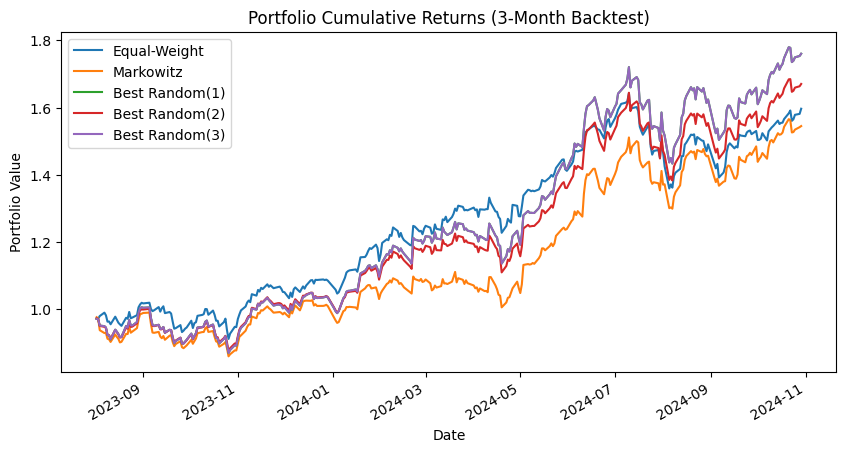

In [36]:
import matplotlib.pyplot as plt
# plot the performance
cumulative_returns = pd.DataFrame({
    'Equal-Weight': (1 + eq_portfolio_ret_1).cumprod(),
    'Markowitz': (1 + mw_portfolio_ret_1).cumprod(),
    'Best Random(1)': (1 + rnd_portfolio_ret_1).cumprod(),
    'Best Random(2)': (1 + rnd_portfolio_ret_2).cumprod(),
    'Best Random(3)': (1 + rnd_portfolio_ret_3).cumprod()

})

cumulative_returns.plot(figsize=(10, 5), title='Portfolio Cumulative Returns (3-Month Backtest)')
plt.ylabel("Portfolio Value")
plt.show()

# Step 4: Black-Litterman
1. Find recent news, headlines, analyst reports, etc. that can be quantitatively
translated into new values of returns and volatilities within the Black-Litterman
framework.
2. Apply the BL portfolio optimization. Compare the original portfolio allocation with
the BL results. The comparison should include differences in weights and
performance.
3. Write 1-2 pages of background information. The background information
provides equations, explains the terms in the equation, distinguishes inputs and
outputs, explains how the parameters are estimated and calibrated, gives any
interpretation to what the parameters mean, etc. The background is a technical
summary of how the model works using equations, graphs, figures, tables,
charts, and other illustrations, along with written explanations and
interpretations.

In [37]:
returns = portfolio_daily_returns


Original Expected Returns (pi): [0.0035226  0.00352432 0.00261212 0.0029511  0.00925091]
Black-Litterman Adjusted Returns (pi_bl): [0.00413272 0.00445717 0.0033067  0.00403046 0.01334775]

--- Black-Litterman Optimal Portfolio (Max Sharpe) ---
AAPL: 0.6437
MSFT: 0.0107
GOOG: 0.0000
AMZN: 0.0000
NVDA: 0.3456

Expected Annualized Return: 184.48%
Expected Annualized Volatility: 28.44%
Sharpe Ratio: 6.3592


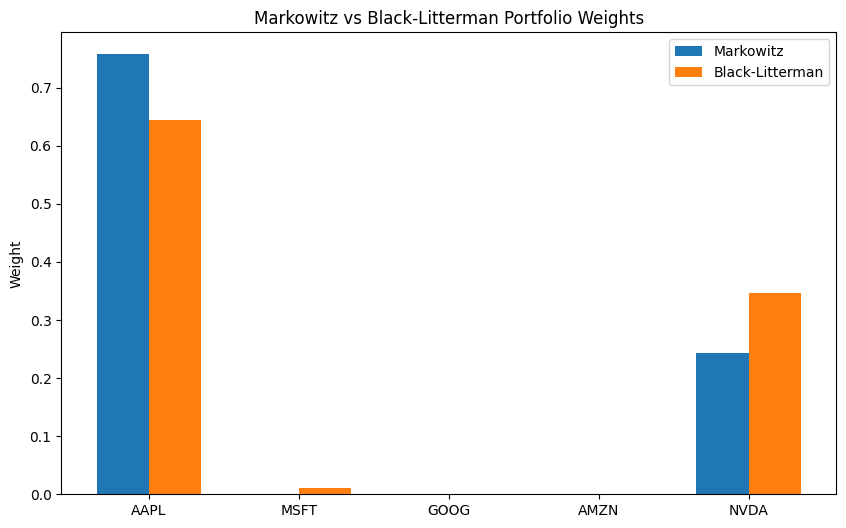

In [38]:
# Step 4: Black-Litterman Model
# Find recent news/headlines to form views.
#News1: Microsoft invests billions more dollars in OpenAI, extends partnership
#News2: “Nvidia shares soar nearly 30% as sales forecast jumps and AI booms”
#News3: Apple second quarter revenue of $94.8 billion down 3% year over year, and all-time high record for service revenue.

# Assumptions:
# We use an equal-weighted portfolio as the market equilibrium prior (pi).
pi = returns.mean().values
tau = 0.05  # A scalar parameter representing the uncertainty of the prior.

# Views setup
#View1: Microsoft will outperform Google in the next quarter by around 6% due to its increasing investment
#View2: View: Nicidia will continue to grow for about 20% with AI bloom
#View3: Apple will outperform Amazon (in service relatives revenue) for about 3%.

P = np.array([
    [0, 1, -1, 0, 0],  # MSFT will outperform GOOG
    [0, 0, 0, 0, 1],   # NVDA will continue to grow for 20%
    [1, 0, 0, -1, 0]   # AAPL will outperform AMZN
])
q = np.array([0.06, 0.2,0.03]) # MSFT-GOOG difference, NVDA absolute return, AAPL-AMZN difference

# Uncertainty matrix of views (Omega)
# Diagonal elements represent the variance of the error term for each view.
# We will use a simple, small diagonal matrix for this example.
omega = np.diag([0.003, 0.003,0.009]) #high confidence in MSFT and NVDA performance, and medium-high confidence in AAPL performance
cov = cov_matrix.values

# Black-Litterman formula implementation
inv_tau_cov = np.linalg.inv(tau * cov)
inv_omega = np.linalg.inv(omega)

middle = np.linalg.inv(inv_tau_cov + P.T @ inv_omega @ P)
rhs = inv_tau_cov @ pi + P.T @ inv_omega @ q
pi_bl = middle @ rhs

print("\nOriginal Expected Returns (pi):", pi)
print("Black-Litterman Adjusted Returns (pi_bl):", pi_bl)


#new Sharpe ratio function for Black-Litterman
def negative_sharpe_bl(weights, bl_returns, cov_matrix, rf_daily):
    ret = np.dot(weights, bl_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    if vol == 0:
        return 0
    sharpe = (ret - rf_daily) / vol
    return -sharpe

#Run the optimization using the BL returns
init_guess_bl = num_assets * [1 / num_assets]
optimized_bl = minimize(
    negative_sharpe_bl,
    init_guess_bl,
    args=(pi_bl, cov, rf_daily),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

#Extract and print Black-Litterman results
opt_weights_bl = optimized_bl.x
expected_return_bl, expected_vol_bl = portfolio_performance(opt_weights_bl, pi_bl, cov)
bl_ret = expected_return_bl * 252
bl_vol = expected_vol_bl * np.sqrt(252)
bl_sharpe = (bl_ret - rf_annual) / bl_vol

print("\n--- Black-Litterman Optimal Portfolio (Max Sharpe) ---")
for ticker, weight in zip(tickers, opt_weights_bl):
    print(f"{ticker}: {weight:.4f}")
print(f"\nExpected Annualized Return: {bl_ret:.2%}")
print(f"Expected Annualized Volatility: {bl_vol:.2%}")
print(f"Sharpe Ratio: {bl_sharpe:.4f}")


# Plot Markowitz vs Black-Litterman weights
plt.figure(figsize=(10, 6))
x = np.arange(num_assets)
width = 0.35
plt.bar(x - width/2, opt_weights, width, label='Markowitz')
plt.bar(x + width/2, opt_weights_bl, width, label='Black-Litterman')
plt.xticks(x, tickers)
plt.ylabel("Weight")
plt.title("Markowitz vs Black-Litterman Portfolio Weights")
plt.legend()
plt.show()

# Step 5: Kelly Criterion
1. Perform back-testing using the Kelly criterion for each security in the portfolio to
size the allocation to that security.
2. Perform a series of historical backtests to see how the combined portfolio
performs.
3. Write 1-2 pages of background information. The background information
provides equations, explains the terms in the equation, distinguishes inputs and
outputs, explains how the parameters are estimated and calibrated, gives any
interpretation to what the parameters mean, etc. The background is a technical
summary of how the model works using equations, graphs, figures, tables,
charts, and other illustrations, along with written explanations and
interpretations.


--- Full Kelly Criterion Fractions (F) ---
AAPL: 18.5510
MSFT: 3.0285
GOOG: -4.6378
AMZN: -4.1108
NVDA: 5.5740

--- Full Kelly Criterion Normalized Weights ---
AAPL: 0.6832
MSFT: 0.1115
GOOG: 0.0000
AMZN: 0.0000
NVDA: 0.2053


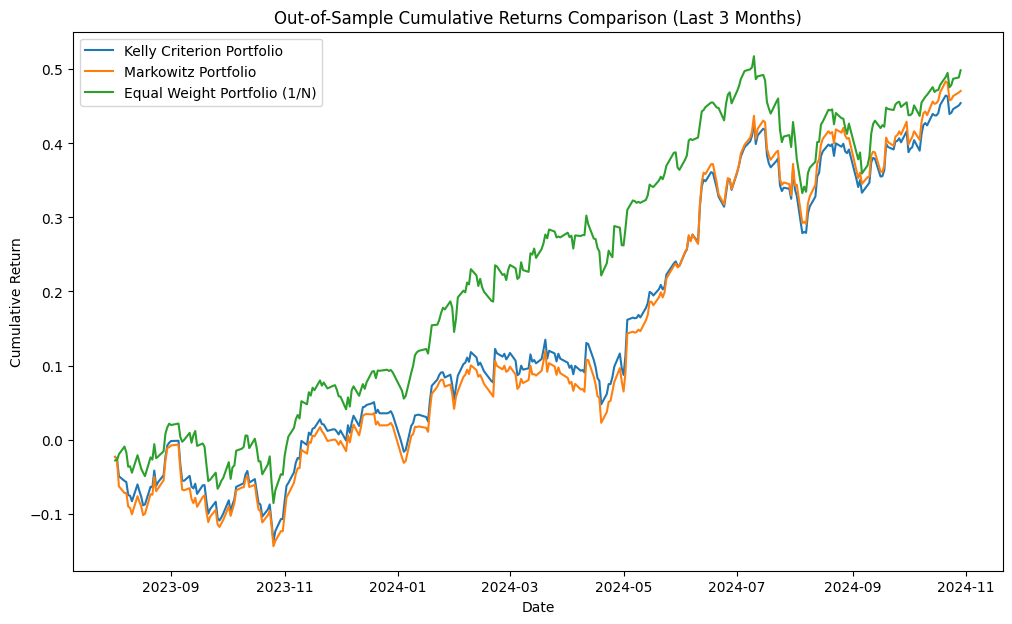

In [39]:
# Assume 'returns' is your DataFrame of daily returns
# and 'rf_daily' is your daily risk-free rate

# --- Full Multi-Asset Kelly Criterion ---

# Step 1: Calculate excess returns and the covariance matrix
mean_excess_returns = returns.mean() - rf_daily
cov_matrix = returns.cov()

# Step 2: Calculate the inverse of the covariance matrix
try:
    inv_cov_matrix = np.linalg.inv(cov_matrix)
except np.linalg.LinAlgError:
    # Handle cases where the matrix is singular
    # Using the pseudo-inverse is a common fallback
    print("Warning: Covariance matrix is singular, using pseudo-inverse.")
    inv_cov_matrix = np.linalg.pinv(cov_matrix)

# Step 3: Calculate the optimal Kelly fractions
full_kelly_fractions = inv_cov_matrix @ mean_excess_returns

print("\n--- Full Kelly Criterion Fractions (F) ---")
for ticker, f in zip(tickers, full_kelly_fractions):
    print(f"{ticker}: {f:.4f}")

# Step 4: Normalize the fractions to get portfolio weights
full_kelly_fractions[full_kelly_fractions < 0] = 0
kelly_weights_full = full_kelly_fractions / np.sum(full_kelly_fractions)


print("\n--- Full Kelly Criterion Normalized Weights ---")
for ticker, w in zip(tickers, kelly_weights_full):
    print(f"{ticker}: {w:.4f}")

kelly_returns_oos_full = portfolio_cumulative_return(kelly_weights_full, oos_returns)

plt.figure(figsize=(12, 7))
plt.plot(kelly_returns_oos_full, label='Kelly Criterion Portfolio')
plt.plot(markowitz_returns_oos_s3, label='Markowitz Portfolio')
plt.plot(eq_returns_oos_s3, label='Equal Weight Portfolio (1/N)')
plt.title('Out-of-Sample Cumulative Returns Comparison (Last 3 Months)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [40]:
# Backtest the Black-Litterman optimized portfolio
bl_portfolio_ret = get_portfolio_returns(backtest_returns, opt_weights_bl)

# Calculate cumulative return, volatility, and Sharpe ratio for Black-Litterman
bl_cum_return = (1 + bl_portfolio_ret).prod() - 1
bl_portfolio_vol = np.std(bl_portfolio_ret) * np.sqrt(252)
bl_portfolio_sharpe = (np.mean(bl_portfolio_ret) * 252 - rf_annual) / bl_portfolio_vol


# Backtest the Kelly Criterion optimized portfolio
kelly_portfolio_ret = get_portfolio_returns(backtest_returns, kelly_weights_full)

# Calculate cumulative return, volatility, and Sharpe ratio for Kelly Criterion
kelly_cum_return = (1 + kelly_portfolio_ret).prod() - 1
kelly_portfolio_vol = np.std(kelly_portfolio_ret) * np.sqrt(252)
kelly_portfolio_sharpe = (np.mean(kelly_portfolio_ret) * 252 - rf_annual) / kelly_portfolio_vol

3-Month Backtest Summary with Black-Litterman and Kelly Criterion:


,Cumulative Return (3M),Volatility (Annualized),Sharpe Ratio
Equal-Weight,59.69%,22.05%,1.6509
Markowitz,54.53%,23.81%,1.4347
Monte Carlo(1) - Max Sharpe Ratio,76.05%,25.98%,1.7393
Monte Carlo(2) - Max Sharpe Ratio,67.06%,24.23%,1.6729
Monte Carlo(3) - Max Sharpe Ratio,76.05%,25.98%,1.7393
Black-Litterman,71.40%,25.92%,1.6596
Kelly Criterion,52.54%,22.62%,1.4522



3-Month Backtest Weight Summary with Black-Litterman and Kelly Criterion:


,Equal-Weight,Markowitz,Monte Carlo (1),Monte Carlo (2),Monte Carlo (3),Black-Litterman,Kelly Criterion
AAPL,0.2000,0.7573,0.5409,0.5490,0.5409,0.6437,0.6832
MSFT,0.2000,0.0000,0.0666,0.0500,0.0666,0.0107,0.1115
GOOG,0.2000,0.0000,0.0133,0.0091,0.0133,0.0000,0.0000
AMZN,0.2000,0.0000,0.0213,0.0901,0.0213,0.0000,0.0000
NVDA,0.2000,0.2427,0.3578,0.3019,0.3578,0.3456,0.2053


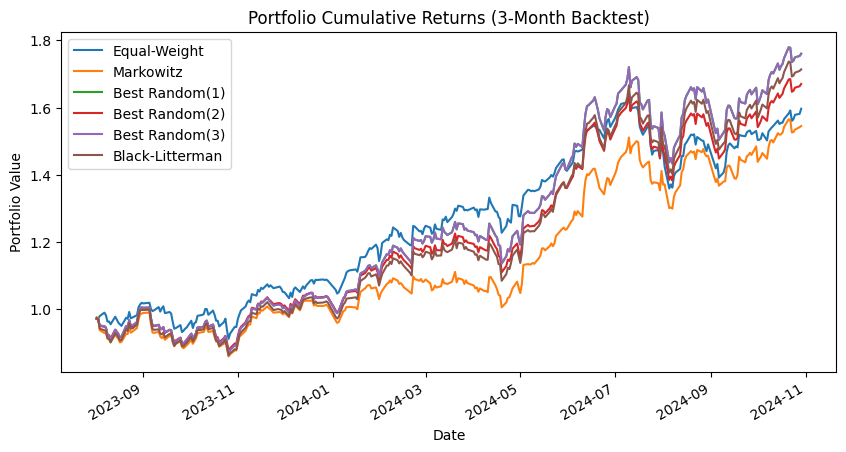

In [41]:
# Add Black-Litterman and Kelly Criterion results to the backtest summary
backtest_summary_all = backtest_summary.copy()
backtest_summary_all.loc['Black-Litterman'] = [bl_cum_return, bl_portfolio_vol, bl_portfolio_sharpe]
backtest_summary_all.loc['Kelly Criterion'] = [kelly_cum_return, kelly_portfolio_vol, kelly_portfolio_sharpe]

print("3-Month Backtest Summary with Black-Litterman and Kelly Criterion:")
display(backtest_summary_all.style.format({
    'Cumulative Return (3M)': '{:.2%}',
    'Volatility (Annualized)': '{:.2%}',
    'Sharpe Ratio': '{:.4f}'
}))

# Add Black-Litterman weights to the weight summary
backtest_weight_all = backtest_weight.copy()
backtest_weight_all['Black-Litterman'] = opt_weights_bl
backtest_weight_all['Kelly Criterion'] = kelly_weights_full

print("\n3-Month Backtest Weight Summary with Black-Litterman and Kelly Criterion:")
display(backtest_weight_all.map(lambda x: f"{x:.4f}"))

# Plot cumulative returns including Black-Litterman
cumulative_returns_bl = cumulative_returns.copy()
cumulative_returns_bl['Black-Litterman'] = (1 + bl_portfolio_ret).cumprod()

cumulative_returns_bl.plot(figsize=(10, 5), title='Portfolio Cumulative Returns (3-Month Backtest)')
plt.ylabel("Portfolio Value")
plt.show()

In [42]:
correlation_matrix = returns.corr()
print("--- Asset Correlation Matrix ---")
print(correlation_matrix)

--- Asset Correlation Matrix ---
          AAPL      MSFT      GOOG      AMZN      NVDA
AAPL  1.000000  0.552848  0.608471  0.580983  0.413949
MSFT  0.552848  1.000000  0.639587  0.643145  0.296787
GOOG  0.608471  0.639587  1.000000  0.636914  0.352577
AMZN  0.580983  0.643145  0.636914  1.000000  0.534532
NVDA  0.413949  0.296787  0.352577  0.534532  1.000000
